In [1]:
import logging
import matplotlib.pyplot as plt
import numpy as np
import os
import json

##### Drawing function for the plottings


In [2]:
# drawing one category per once
def draw_figure(x_values, y_values, num_secs, plot_label, plot_color, x_label, y_label, title, output_path):
    plt.figure(figsize=(12, 8))
    y_values = np.array(y_values)
    dim = y_values.ndim
    if dim >= 2:
        assert len(y_values) == len(plot_label) == len(plot_color), \
            "Lengths of y_values, plot_label, and plot_color must match."
            
        for i, y_value in enumerate(y_values):
            plt.plot(x_values, y_value, label=plot_label[i], color=plot_color[i], linewidth=2)
    else:
        plt.plot(x_values, y_values, label=plot_label, color=plot_color, linewidth=2)
    plt.legend()
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)
    plt.grid(True)
    plt.xticks(np.arange(start=min(x_values), stop=max(x_values)+1, step=max(x_values) // num_secs))
    plt.savefig(output_path)

below functions are used to quickly analyze how much training goes

In [3]:
def visualize_plots(basic_path, config_filename, run, exe_time, verbose=True):
    vis_data = []
    try:
        with open(basic_path + f'/{config_filename}/{run}/{exe_time}/vis_data/{exe_time}.json', 'r') as f:
            for line in f:
                vis_data.append(json.loads(line.strip()))
    except FileNotFoundError:
        print(f"{basic_path}/{config_filename}/{run}/{exe_time}/vis_data/{exe_time}.json not found. skip visualization.")
        return
    
    epochs = []
    iters = []
    loss = []
    grad_norm = []

    loss_cls = []
    loss_reg_xytl = []
    loss_iou = []
    loss_seg = []
    loss_dpp = []
    
    num_assign = []
    total_assign = []
    
    val_epochs = []
    val_precision_01 = []
    val_recall_01 = []
    val_f1_01 = []
    
    val_precision_05 = []
    val_recall_05 = []
    val_f1_05 = []
    
    val_precision_075 = []
    val_recall_075 = []
    val_f1_075 = []
    
    for data in vis_data:
        if 'TP0.1' not in data:
            epochs.append(data['epoch'])
            iters.append(data['iter'])
            loss.append(data['loss'])
            loss_cls.append(data['loss_cls'])
            loss_reg_xytl.append(data['loss_reg_xytl'])
            loss_iou.append(data['loss_iou'])
            loss_seg.append(data['loss_seg'])
            
            if "loss_dpp" in data.keys():
                loss_dpp.append(data["loss_dpp"])
            
            if "num_assignment" in data.keys():
                num_assign.append(data["num_assignment"])
                total_assign.append(data["total_assignment"])

            if 'grad_norm' in data.keys():
                grad_norm.append(data['grad_norm'])
        else:
            val_epochs.append(epochs[-1])
            
            val_precision_01.append(data['Precision0.1'])
            val_recall_01.append(data['Recall0.1'])
            val_f1_01.append(data['F1_0.1'])
            
            val_precision_05.append(data['Precision0.5'])
            val_recall_05.append(data['Recall0.5'])
            val_f1_05.append(data['F1_0.5'])
            
            val_precision_075.append(data['Precision0.75'])
            val_recall_075.append(data['Recall0.75'])
            val_f1_075.append(data['F1_0.75'])
    
    if len(grad_norm) != 0:
        draw_figure(
            x_values=iters,
            y_values=grad_norm,
            num_secs=max(epochs),
            plot_label='Gradient Norm',
            plot_color='blue',
            x_label='Iterations (every 100 steps)',
            y_label='Grad Norm',
            title='Gradient Norm Curve',
            output_path=basic_path + f'/{config_filename}/{run}/{exe_time}/grad_norm.png'
        )
    else:
        print("No grad_norm data found, skipping grad_norm plotting.")

    draw_figure(
        x_values=iters,
        y_values=loss,
        num_secs=max(epochs),
        plot_label='Total Loss',
        plot_color='blue',
        x_label='Iterations (every 100 steps)',
        y_label='Loss',
        title='Training Loss Curve',
        output_path=basic_path + f'/{config_filename}/{run}/{exe_time}/train_loss.png'
    )
    
    draw_figure(
        x_values=iters,
        y_values=loss_cls,
        num_secs=max(epochs),
        plot_label='Classification Loss',
        plot_color='orange',
        x_label='Iterations (every 100 steps)',
        y_label='Loss',
        title='Classification Loss Curve',
        output_path=basic_path + f'/{config_filename}/{run}/{exe_time}/train_loss_cls.png'
    )
    
    draw_figure(
        x_values=iters,
        y_values=loss_reg_xytl,
        num_secs=max(epochs),
        plot_label='Regression Loss (XYTL)',
        plot_color='green',
        x_label='Iterations (every 100 steps)',
        y_label='Loss',
        title='Regression Loss (XYTL) Curve',
        output_path=basic_path + f'/{config_filename}/{run}/{exe_time}/train_loss_reg.png'
    )
    
    draw_figure(
        x_values=iters,
        y_values=loss_iou,
        num_secs=max(epochs),
        plot_label='Ious Loss',
        plot_color='black',
        x_label='Iterations (every 100 steps)',
        y_label='Loss',
        title='IOU Loss Curve',
        output_path=basic_path + f'/{config_filename}/{run}/{exe_time}/train_loss_iou.png'
    )

    draw_figure(
        x_values=iters,
        y_values=loss_seg,
        num_secs=max(epochs),
        plot_label='Segmentation Loss',
        plot_color='purple',
        x_label='Iterations (every 100 steps)',
        y_label='Loss',
        title='Segmentation Loss Curve',
        output_path=basic_path + f'/{config_filename}/{run}/{exe_time}/train_loss_seg.png'
    )
    
    if len(loss_dpp) != 0:
        draw_figure(
            x_values=iters,
            y_values=loss_dpp,
            num_secs=max(epochs),
            plot_label="DPP Loss",
            plot_color="brown",
            x_label="Iterations (every 100 steps)",
            y_label="Loss",
            title="DPP Loss Curve",
            output_path=basic_path + f'/{config_filename}/{run}/{exe_time}/train_loss_dpp.png'
        )
    
    if len(num_assign) != 0:
        draw_figure(
            x_values=iters,
            y_values=[num_assign, total_assign],
            num_secs=max(epochs),
            plot_label=["simOTA num_assign", "simOTA total_assign"],
            plot_color=["magenta", "limegreen"],
            x_label="Iterations (every 100 steps)",
            y_label="Number of assignment",
            title="Number of Assignment by IoU",
            output_path=basic_path + f'/{config_filename}/{run}/{exe_time}/simota_num_assign.png'
        )
    
    draw_figure(
        x_values=val_epochs,
        y_values=[val_precision_01, val_recall_01, val_f1_01],
        num_secs=len(val_epochs),
        plot_label=['Precision@0.1', 'Recall@0.1', 'F1@0.1'],
        plot_color=['blue', 'orange', 'green'],
        x_label='Epochs',
        y_label='Precision, Recall, F1 Score',
        title='Validation Precision, Recall, F1 Score at 0.1 IOU Threshold',
        output_path=basic_path + f'/{config_filename}/{run}/{exe_time}/val_prf_@01.png'
    )
    
    draw_figure(
        x_values=val_epochs,
        y_values=[val_precision_05, val_recall_05, val_f1_05],
        num_secs=len(val_epochs),
        plot_label=['Precision@0.5', 'Recall@0.5', 'F1@0.5'],
        plot_color=['blue', 'orange', 'green'],
        x_label='Epochs',
        y_label='Precision, Recall, F1 Score',
        title='Validation Precision, Recall, F1 Score at 0.5 IOU Threshold',
        output_path=basic_path + f'/{config_filename}/{run}/{exe_time}/val_prf_@05.png'
    )
    
    draw_figure(
        x_values=val_epochs,
        y_values=[val_precision_075, val_recall_075, val_f1_075],
        num_secs=len(val_epochs),
        plot_label=['Precision@0.75', 'Recall@0.75', 'F1@0.75'],
        plot_color=['blue', 'orange', 'green'],
        x_label='Epochs',
        y_label='Precision, Recall, F1 Score',
        title='Validation Precision, Recall, F1 Score at 0.75 IOU Threshold',
        output_path=basic_path + f'/{config_filename}/{run}/{exe_time}/val_prf_@075.png'
    )
    

    if not verbose:
        plt.close('all')
    

In [4]:
basic_path = '/work/CLRerNet/work_dirs'
# config_filename = 'clrernet_culane_dla34'
# run = 'exp'
# exe_time = '20251028_174729'

config_filename = "clrernet_culane_dla34"
run = "run1"
exe_time = "20250717_022217"


visualize_plots(basic_path, config_filename, run, exe_time, verbose=False)

No grad_norm data found, skipping grad_norm plotting.


In [4]:
def visualize_folder(basic_path, config_filename):
    runs = os.listdir(basic_path + f'/{config_filename}')
    for run in runs:
        print(f"Visualizing {run}...")
        if os.path.isdir(basic_path + f'/{config_filename}/{run}'):
            executions = os.listdir(basic_path + f'/{config_filename}/{run}/')
            for execution in executions:
                if os.path.isdir(basic_path + f'/{config_filename}/{run}/{execution}'):
                    print(f"Visualizing: {basic_path + f'/{config_filename}/{run}/{execution}'}")
                    visualize_plots(basic_path, config_filename, run, execution, verbose=False)

In [5]:
basic_path = '/work/CLRerNet/work_dirs'

# config_filename = 'clrernet_culane_segman_encdec_ssmfpn'
# visualize_folder(basic_path, config_filename)

# config_filename = 'clrernet_culane_segman_ssmfpn'
# visualize_folder(basic_path, config_filename)

#config_filename2 = 'clrernet_culane_segman'
#visualize_folder(basic_path, config_filename2)

# config_filename = 'clrernet_culane_dla34_segman_dec_ssmfpn'
# visualize_folder(basic_path, config_filename)

# config_filename3 = 'clrernet_culane_dla34_ssmfpn'
# visualize_folder(basic_path, config_filename3)

# config_filename4 = 'clrernet_culane_dla34'
# visualize_folder(basic_path, config_filename4)

# config_filename5 = 'clrernet_culane_segman_encdec_ssmfpn_attnhead'
# visualize_folder(basic_path, config_filename5)

# config_filename6 = 'clrernet_culane_segman_encdec_ssmfpn_atss'
# visualize_folder(basic_path, config_filename6)

# config_filename7 = 'clrernet_culane_dla34_atss'
# visualize_folder(basic_path, config_filename7)

# config_filename8 = 'clrernet_culane_segman_encdec_rcfpn'
# visualize_folder(basic_path, config_filename8)

#config_filename9 = 'clrernet_culane_segman_encdec'
#visualize_folder(basic_path, config_filename9)

# config_filename10 = 'clrernet_culane_segman_encdec_attnplus'
# visualize_folder(basic_path, config_filename10)

# config_filename11 = 'clrernet_culane_segman_encdec_rcformer'
# visualize_folder(basic_path, config_filename11)

# config_filename12 = 'clrernet_culane_segman_rcformer'
# visualize_folder(basic_path, config_filename12)

# config_filename13 = 'clrernet_culane_segman_encdec_decneck'
# visualize_folder(basic_path, config_filename13)

# config_filename14 = 'clrernet_culane_segman_decneck'
# visualize_folder(basic_path, config_filename14)

# config_filename15 = 'clrernet_culane_segman_encdec_rcformer_attnplus'
# visualize_folder(basic_path, config_filename15)

# config_filename16 = 'clrernet_culane_dla34_context_anchor'
# visualize_folder(basic_path, config_filename16)

# config_filename17 = 'clrernet_culane_dla34_rowcol_attn'
# visualize_folder(basic_path, config_filename17)

# config_filename18 = 'clrernet_culane_dla34_gsrc'
# visualize_folder(basic_path, config_filename18)

# config_filename19 = 'clrernet_culane_dla34_cls_anchor'
# visualize_folder(basic_path, config_filename19)

# config_filename20 = 'clrernet_culane_dla34_rc_fpn'
# visualize_folder(basic_path, config_filename20)

config_filename21 = 'clrernet_culane_dla34_rc_fpn_v2_head'
visualize_folder(basic_path, config_filename21)

config_filename22 = 'clrernet_culane_dla34_gsrc_v2_head'
visualize_folder(basic_path, config_filename22)

config_filename23 = 'clrernet_culane_swin_gsrc_v2_head'
visualize_folder(basic_path, config_filename23)

config_filename24 = 'clrernet_culane_segman_gsrc_v2_head'
visualize_folder(basic_path, config_filename24)

Visualizing run1...
Visualizing: /work/CLRerNet/work_dirs/clrernet_culane_dla34_rc_fpn_v2_head/run1/20260120_191825
No grad_norm data found, skipping grad_norm plotting.
Visualizing test2...
Visualizing: /work/CLRerNet/work_dirs/clrernet_culane_dla34_rc_fpn_v2_head/test2/20260122_141938
/work/CLRerNet/work_dirs/clrernet_culane_dla34_rc_fpn_v2_head/test2/20260122_141938/vis_data/20260122_141938.json not found. skip visualization.
Visualizing test1...
Visualizing: /work/CLRerNet/work_dirs/clrernet_culane_dla34_rc_fpn_v2_head/test1/20260121_182902
/work/CLRerNet/work_dirs/clrernet_culane_dla34_rc_fpn_v2_head/test1/20260121_182902/vis_data/20260121_182902.json not found. skip visualization.
Visualizing run2...
Visualizing: /work/CLRerNet/work_dirs/clrernet_culane_dla34_rc_fpn_v2_head/run2/20260121_200233
No grad_norm data found, skipping grad_norm plotting.
Visualizing run1...
Visualizing: /work/CLRerNet/work_dirs/clrernet_culane_dla34_gsrc_v2_head/run1/20260121_203114
No grad_norm data fo

#### Visualization compared to specific model vs model

In [ ]:
# class that contains various drawing function set
class Drawer:
    
    @staticmethod
    def drawer_style1(figure_size, x_values, y_values, step_size, plot_label, plot_color, x_label, y_label, title, out_path, verbose=False):
        """
        matplotlib based drawing tool.
config_filename16 = 'clrernet_culane_dla34_context_anchor'
visualize_folder(basic_path, config_filename16)

        parameters:
            figure_size (tuple): figure size to desire
            x_values    (list): list of x values (across different files)
            y_values    (list or dict[list]): list of y values (across different files). if it is empty sequence, ignore the values
                if it is given as dictionary, each key corresponds to different types of list of y values (across different files)
                if you want to visualize different types of y value at once on one plot, give it as dictionary
            step_size   (int):  step size of x axis. if none, automatically determined
            plot_label  (list[str]): list of the labels
            plot_color  (list[str]): list of the plot color
            x_label     (str): label of x
            y_label     (str): label of y
            title       (str): title of the plot
            out_path    (str): output path for saving plots
        """
        
        assert type(y_values) in [dict, list], "y_values must be given as list or dictionary!"
        
        # create window
        plt.figure(figsize=figure_size)

        # if y_values given as dictionary, iterate through it to visualize all the elements
        count = 0
        if isinstance(y_values, dict):
            for key in y_values.keys():
                y_value = y_values[key]
                for xy_values in zip(x_values, y_value):
                    x, y = xy_values
                    plt.plot(x, y, label=plot_label[count], color=plot_color[count], linewidth=2)
                    plt.legend()
                    count += 1
        else:
            if len(y_values) == 0:
                print("skipping the visualization because of empty y_values sequence!")
                return
            # i is index for different files
            for i, xy_values in enumerate(zip(x_values, y_values)):
                x, y = xy_values
                plt.plot(x, y, label=plot_label[i], color=plot_color[i], linewidth=2) # linewidth set to 2
                plt.legend()

        plt.xlabel(x_label)
        plt.ylabel(y_label)
        plt.title(title)
        plt.grid(True)
        plt.xticks(np.arange(start=min([min(x) for x in x_values]), stop=max([max(x) for x in x_values])+1, step=step_size))
        plt.savefig(out_path)

        # only visualize on the window if the verbose sets to True
        if not verbose:
            plt.close()


In [ ]:
def visualizer(json_files, plot_label, out_path):
    """
    parameters:
        json_files (List["str"]): list that contains json file path. (training folder will contain it in the vis_data folder)
        plot_label (List["str"]): list of labels for plot.
        out_path   ("str"): output path of the plots.
    """
    
    if not os.path.exists(out_path):
        os.makedirs(out_path)

    jsons = []
    for json_file in json_files:
        json_data = []
        try:
            # read line by line (whole json files are in wrong format. must be read in line by line)
            with open(json_file, 'r') as f:
                for line in f:
                    json_data.append(json.loads(line.strip()))
        except FileNotFoundError:
            print(f"{json_file} not found. skip visualization.")
            continue
        jsons.append(json_data)
    
    data = dict()
    keys = ["all_epochs", "all_iters", "all_grad_norm", "all_loss", "all_loss_cls", "all_reg_xytl", "all_loss_iou", 
            "all_loss_seg", "all_loss_dpp", "all_assignment", "all_total_assignment", "all_val_epochs", "all_val_precision_01", "all_val_recall_01", "all_val_f1_01", 
            "all_val_precision_05", "all_val_recall_05", "all_val_f1_05",
            "all_val_precision_075", "all_val_recall_075", "all_val_f1_075"]

    keys_per_file = ["epoch", "iter", "grad_norm", "loss", "loss_cls", "loss_reg_xytl", "loss_iou", "loss_seg", "loss_dpp", "assignment", "total_assignment", 
                     "val_epochs", "val_precision_01", "val_recall_01", "val_f1_01", "val_precision_05", "val_recall_05",
                     "val_f1_05", "val_precision_075", "val_recall_075", "val_f1_075"]

    line_format1 = ['epoch', 'iter', 'grad_norm', 'loss', 'loss_cls', 'loss_reg_xytl', 'loss_iou', 'loss_seg', 'loss_dpp', "assignment", "total_assignment"]
    line_format2 = ["step", "Precision0.1", "Recall0.1", "F1_0.1", "Precision0.5", "Recall0.5", "F1_0.5", "Precision0.75", "Recall0.75", "F1_0.75"]
    data_inner_format2 = ["val_epochs", "val_precision_01", "val_recall_01", "val_f1_01", "val_precision_05", "val_recall_05",
                          "val_f1_05", "val_precision_075", "val_recall_075", "val_f1_075"]
    
    assert len(keys)==len(keys_per_file)

    # initialized with empty list
    for key in keys:
        data[key] = []

    # iterate through the json files
    for json_data in jsons:

        data_inner = dict()
        skip_flag = dict()
        for key in keys_per_file:
            data_inner[key] = [] # initialize it with empty list
            skip_flag[key] = False # flag dictionary to judge whether to skip the retrieving.

        # iterate through line by line in json_data
        for line in json_data:
            if 'TP0.1' not in line.keys():
                for key in line_format1:
                    if skip_flag[key]: # if 'skip' flag set for True
                        continue # skip the retreiving process...

                    if key in line.keys():
                        data_inner[key].append(line[key])
                    else:
                        data_inner[key] = []
                        print(f"Key {key} not found in the source. skipping the retrieving...")
                        skip_flag[key] = True

            else:
                for i, key in enumerate(line_format2):
                    if skip_flag[data_inner_format2[i]]: # if 'skip' flag set for True
                        continue # skip the retreiving process...

                    if key in line.keys():
                        data_inner[data_inner_format2[i]].append(line[key])
                    else:
                        data_inner[data_inner_format2[i]] = []
                        print(f"Key {key} not found in the source. skipping the retrieving...")
                        skip_flag[data_inner_format2[i]] = True

        # retrieve data from the extracted files
        for i, key in enumerate(keys):
            if len(data_inner[keys_per_file[i]]) == 0: # if the retrieved source is empty sequence.
                data_inner[keys_per_file[i]] = [] # add with empty list
            data[key].append(data_inner[keys_per_file[i]])

    # find the maximum epoch!
    max_epoch = max([max(t) for t in data["all_epochs"]])
    max_iter = max([max(t) for t in data["all_iters"]])

    visualize_target= ["Grad Norm", "Total Loss", "CLS Loss", "Reg Loss (XYTL)", "IOU Loss", "Segmentation Loss", "DPP Loss", "Num Assignment", "Num Total Assignment"]
    figure_size= (12, 8)
    target_x_values= ["all_iters", "all_val_epochs"]
    target_y_values= ["all_grad_norm", "all_loss", "all_loss_cls", "all_reg_xytl", "all_loss_iou", "all_loss_seg", "all_loss_dpp", "all_assignment", "all_total_assignment"]
    step_size= max_iter//max_epoch # visualize per (max_iterations//max_epoch)
    plot_label= plot_label
    plot_color= ["blue", "red", "black", "limegreen", "darkorange", "darkmagenta", "cyan", "slategray", "chocolate", "saddlebrown", "violet",
                 "deeppink", "hotpink", "pink", "steelblue", "wheat", "tan", "olivedrab"] # see the https://matplotlib.org/stable/gallery/color/named_colors.html
    x_label= "Iterations"
    y_label= "Loss value"
    title= ["Gradient Norm", "Training Loss", "Classification Loss", "Regression Loss (XYTL)", "IoU Loss", "Segmentation Loss", "DPP Loss", "Number of Assignment", "Number of Total Assignment"]
    out_file= ["grad_norm", "train_loss", "cls_loss", "xytl_loss", "iou_loss", "segmentation_loss", "dpp_loss", "num_assignment", "num_total_assignment"]

    for i, t in enumerate(visualize_target, 0):
        skip = False
        for ii in range(len(data[target_y_values[i]])):
            if len(data[target_y_values[i]][ii]) == 0:
                skip=True
            break
                
        # if one of the files contains the target_y_values that is length 0, skip the visualization
        if skip:
            continue
        Drawer.drawer_style1(figure_size=figure_size, x_values=data[target_x_values[0]], y_values=data[target_y_values[i]], 
               step_size=step_size, plot_label=plot_label, plot_color=plot_color, x_label=x_label, y_label=y_label, title=title[i], out_path=os.path.join(out_path, out_file[i]+'.png'))
    
    # Because most values of precision, recall, f1 score are very similar each other for different files, visualizing it separately is more recommendable...
    visualize_target2= ["Val Precision, Recall, F1 at @01 threshold", "Val Precision, Recall, F1 at @05 threshold", "Val Precision, Recall, F1 at @075 threshold"]
    target_y_values2= [["all_val_precision_01", "all_val_recall_01", "all_val_f1_01"],
                       ["all_val_precision_05", "all_val_recall_05", "all_val_f1_05"],
                       ["all_val_precision_075", "all_val_recall_075", "all_val_f1_075"]]

    step_size= 3 # visualize per 3 epoch (evaluated per 3 epochs)
    plot_label_i = []
    plot_label_t = ["Precision", "Recall", "F1"]
    plot_label= plot_label
    for t in plot_label_t:
        for j in plot_label:
            plot_label_i.append(t + " " + j)
    x_label2= "Epochs"
    y_label2= "Precision, Recall, F1 Score"
    title2= ["Val Precision, Recall, F1 Score at IoU 0.1 threshold", "Val Precision, Recall, F1 Score at IoU 0.5 threshold",
             "Val Precision, Recall, F1 Score at IoU 0.75 threshold"]
    out_file2= ["PRF01", "PRF05", "PRF075"]

    for i, t in enumerate(visualize_target2):
        target_ys = target_y_values2[i]
        input_y = dict()
        for target in target_ys:
            input_y[target] = data[target]
        Drawer.drawer_style1(figure_size=figure_size, x_values=data[target_x_values[1]], y_values=input_y,
            step_size=step_size, plot_label=plot_label_i, plot_color=plot_color, x_label=x_label2, y_label=y_label2, title=title2[i], out_path=os.path.join(out_path, out_file2[i]+'.png'))

    # not visualizing on the jupyter window.
    plt.close('all')

In [16]:
a = ['a', 'b', 'c']
a = ['hello' + x for x in a]
a

['helloa', 'hellob', 'helloc']

In [17]:
basic_path = "/work/CLRerNet/work_dirs"
json_f1 = os.path.join(basic_path, "clrernet_culane_dla34/run1/20250717_022217/vis_data/20250717_022217.json")
json_f2 = os.path.join(basic_path, "clrernet_culane_segman/run1/20250717_160046/vis_data/20250717_160046.json")
json_f3 = os.path.join(basic_path, "clrernet_culane_segman/run3/20250912_154813/vis_data/20250912_154813.json")

# basic_path = "/home/ysy/Documents/visualizer"
# json_f1 = os.path.join(basic_path, "20250717_022217.json")
# json_f2 = os.path.join(basic_path, "20250717_160046.json")
# json_f3 = os.path.join(basic_path, "20250912_154813.json")


visualizer(json_files=[json_f1, json_f2, json_f3], plot_label=["dla34", "segman_tiny", "segman_small"], out_path='/work/CLRerNet/figures/dla34_vs_segman_t_s')
# visualizer(json_files=[json_f1, json_f2, json_f3], plot_label=["dla34", "segman_tiny", "segman_small"], out_path=os.path.join(basic_path, "figures"))

Key grad_norm not found in the source. skipping the retrieving...
Key assignment not found in the source. skipping the retrieving...
Key total_assignment not found in the source. skipping the retrieving...
Key grad_norm not found in the source. skipping the retrieving...
Key assignment not found in the source. skipping the retrieving...
Key total_assignment not found in the source. skipping the retrieving...
Key grad_norm not found in the source. skipping the retrieving...
Key assignment not found in the source. skipping the retrieving...
Key total_assignment not found in the source. skipping the retrieving...


In [40]:
basic_path = "/work/CLRerNet/work_dirs"
json_f1 = os.path.join(basic_path, "clrernet_culane_segman/run3/20250912_154813/vis_data/20250912_154813.json")
json_f2 = os.path.join(basic_path, "clrernet_culane_segman_ssmfpn/run8/20250916_175612/vis_data/20250916_175612.json")

visualizer(json_files=[json_f1, json_f2], plot_label=["segman_small", "segman_small_ssmfpn"], out_path='/work/CLRerNet/figures/segman_s_vs_segman_s_ssmfpn')

Key grad_norm not found in the source. skipping the retrieving...


In [42]:
basic_path = "/work/CLRerNet/work_dirs"
json_f1 = os.path.join(basic_path, "clrernet_culane_segman/run3/20250912_154813/vis_data/20250912_154813.json")
json_f2 = os.path.join(basic_path, "clrernet_culane_segman_encdec/run3/20250915_152309/vis_data/20250915_152309.json")

visualizer(json_files=[json_f1, json_f2], plot_label=["segman_small", "segman_small_encdec"], out_path='/work/CLRerNet/figures/segman_s_vs_segman_s_encdec')

Key grad_norm not found in the source. skipping the retrieving...
Key grad_norm not found in the source. skipping the retrieving...


#### Test Your Figure Size!

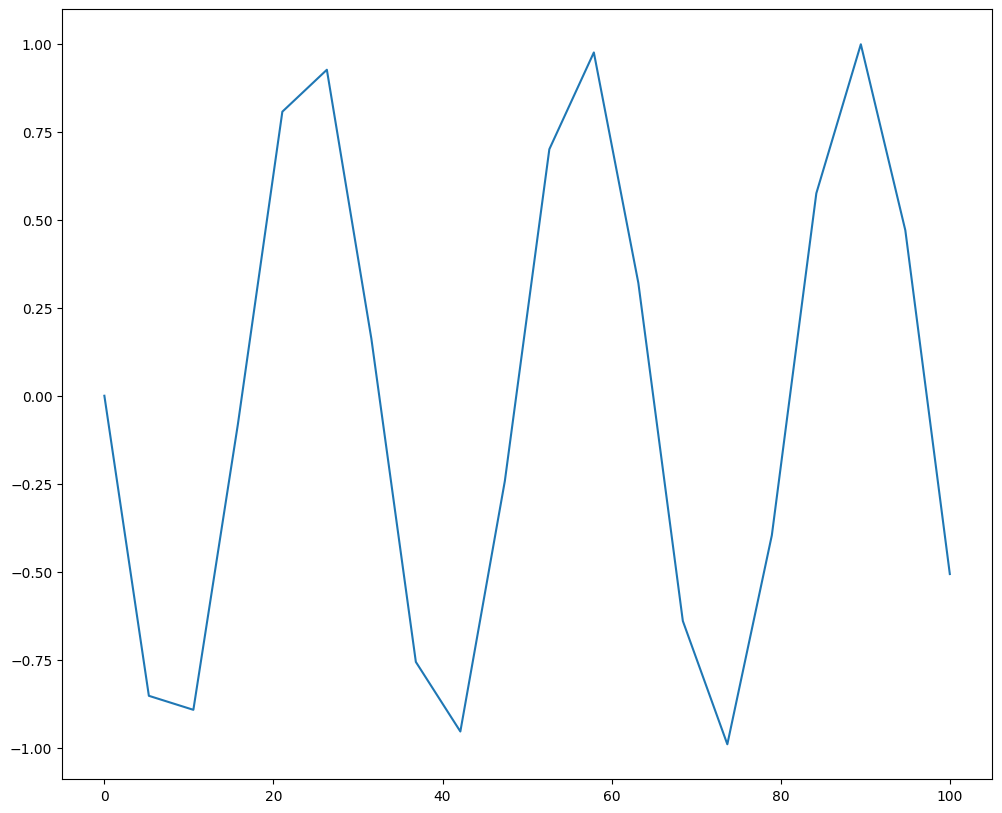

In [12]:
import numpy as np
import matplotlib.pyplot as plt
X = np.linspace(0,100,20)
Y1 = X
Y2 = X**2
Y3 = np.sin(X)
plt.figure(figsize=(12,10))
plt.plot(X,Y3)
plt.show()

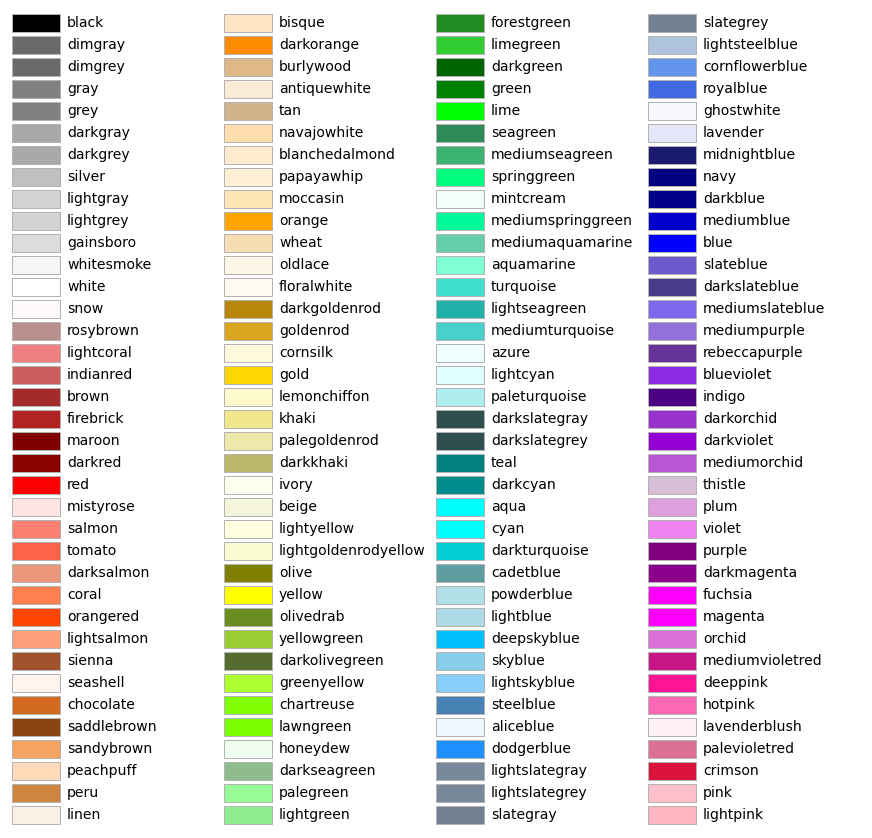

In [17]:
a = [1,2,3,4,5]
b = [5,6,7,8,9]

for i, ab in enumerate(zip(a, b)):
    a, b = ab
    print("i: ", i)
    print("a: ", a)
    print("b: ", a)

i:  0
a:  1
b:  1
i:  1
a:  2
b:  2
i:  2
a:  3
b:  3
i:  3
a:  4
b:  4
i:  4
a:  5
b:  5


False